Create silver and gold inference samples, based on training sample parameter space

In [24]:
import pandas as pd
import numpy as np
import os
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
#from plot_for_aida import plot_heatmaps

import matplotlib
import matplotlib.pylab as pylab
matplotlib.rcParams.update({'errorbar.capsize': 1})
pylab_params = {'legend.fontsize': 'large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large'}
pylab.rcParams.update(pylab_params)

path = '/Users/chrislam/Desktop/cannon-ages/' 
#path = '/home/c.lam/blue/cannon-ages/'

In [25]:
# training sample
training = pd.read_csv(path+'data/4_fold_cv_no_rgb.csv') # 4_fold_cv.csv, 4_fold_cv_ruwe.csv, 4_fold_cv_teff.csv, 4_fold_cv_teff_ruwe.csv, 4_fold_cv_no_rgb.csv
training = training.loc[training['KIC']!=7976303]
training = training.loc[training['KIC']!=10454113]
print("training")
print(training)

# inference sample
### inference set
inferences_df = pd.read_csv(path+'data/inferences_kic_no_rgb.csv', sep=',')
inferences_df['KIC'] = inferences_df['kepid']
print("inference")
print(inferences_df)

training
          KIC       Teff  e_Teff    M_H  e_M_H    Rad  E_Rad  e_Rad  sysrad  \
0     1435467  6111.8910    86.0 -0.028  0.099  1.693  0.015 -0.016   0.010   
1     2010607  6102.5083    71.0 -0.070  0.100  2.410  0.100 -0.090   0.035   
2     2450729  5825.0713    59.0 -0.212  0.100  1.758  0.059 -0.056   0.023   
3     2837475  6209.8716    57.0 -0.015  0.100  1.710  0.022 -0.043   0.039   
4     2849125  5959.9210    56.0  0.293  0.101  2.534  0.115 -0.089   0.028   
..        ...        ...     ...    ...    ...    ...    ...    ...     ...   
323  12069127  6084.2295    66.0  0.076  0.100  2.295  0.021 -0.020   0.024   
324  12069569  6081.1600    59.0 -0.109  0.100  2.314  0.086 -0.079   0.040   
325  12117868  5889.1216    51.0 -0.108  0.099  1.326  0.045 -0.042   0.015   
326  12265063  5852.2270    60.0 -0.268  0.101  1.641  0.052 -0.050   0.024   
327  12317678  6330.1455    48.0 -0.300  0.204  1.851  0.019 -0.018   0.029   

      Mass  ...  aspcap_mg_h  aspcap_e_mg_

In [26]:
# convert to latex for Table 1
training_head = training[['KIC','aspcap_teff','aspcap_logg','aspcap_fe_h','aspcap_mg_h','Age','Dnu']].head(n=10)
training_head['aspcap_teff'] = training_head['aspcap_teff'].astype(int)
training_latex = training_head.style.hide(axis="index").format({
    "aspcap_logg": "{:.2f}",
    "aspcap_fe_h": "{:.2f}",
    "aspcap_mg_h": "{:.2f}",
	"Age": "{:.2f}",
	"Dnu": "{:.2f}",
}).to_latex()
print(training_latex)

\begin{tabular}{rrrrrrr}
KIC & aspcap_teff & aspcap_logg & aspcap_fe_h & aspcap_mg_h & Age & Dnu \\
1435467 & 6111 & 3.83 & 0.08 & 0.01 & 2.60 & 70.56 \\
2010607 & 6102 & 3.57 & 0.06 & -0.00 & 2.75 & 42.48 \\
2450729 & 5825 & 3.90 & -0.23 & -0.18 & 6.03 & 61.91 \\
2837475 & 6209 & 3.74 & -0.03 & -0.06 & 1.13 & 75.72 \\
2849125 & 5959 & 3.51 & 0.30 & 0.22 & 2.58 & 41.32 \\
2852862 & 6058 & 3.63 & -0.08 & -0.10 & 2.26 & 53.56 \\
2991448 & 5615 & 3.97 & -0.09 & -0.04 & 6.88 & 61.73 \\
2998253 & 6108 & 4.03 & 0.08 & 0.01 & 2.62 & 87.23 \\
3112152 & 5946 & 3.84 & 0.00 & -0.00 & 3.78 & 65.13 \\
3112889 & 6035 & 3.77 & -0.23 & -0.24 & 3.63 & 53.71 \\
\end{tabular}



In [27]:
def matched_sampling(reference_df, sample_df):

    # normalize variables
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    #X_sample = scaler.fit_transform(sample_df[['teff','logg','feh','mg_h']])
    #X_ref    = scaler.transform(reference_df[['teff','logg','feh','mg_h']])
    #X_sample = scaler.fit_transform(sample_df[['teff', 'logg']])
    #X_ref    = scaler.transform(reference_df[['teff', 'logg']])
    #X_sample = scaler.fit_transform(sample_df[['aspcap_teff', 'aspcap_logg']])
    #X_ref    = scaler.transform(reference_df[['aspcap_teff', 'aspcap_logg']])
    X_sample = scaler.fit_transform(sample_df[['aspcap_teff', 'aspcap_logg', 'aspcap_fe_h', 'aspcap_mg_h']])
    X_ref    = scaler.transform(reference_df[['aspcap_teff', 'aspcap_logg', 'aspcap_fe_h', 'aspcap_mg_h']])
    #X_sample = scaler.fit_transform(sample_df[['aspcap_mg_h']])
    #X_ref    = scaler.transform(reference_df[['aspcap_mg_h']])

    # fit nearest-neighbor index
    from sklearn.neighbors import NearestNeighbors
    scaling_factor = int(np.floor(len(sample_df)/len(reference_df)))
    print("scaling factor: ", scaling_factor)
    nn = NearestNeighbors(n_neighbors=scaling_factor) 
    nn.fit(X_sample)

    # query neighbors for each reference star
    dist, idx = nn.kneighbors(X_ref)
    #print(idx)
    matched_idx = idx.flatten()  
    matched_sample = sample_df.iloc[matched_idx]

    return idx, matched_sample

def tighter_cull4d(reference_df, comparison_df):

    ### limit Teff and logg of sample (inference set) to bounds from reference (training) set
    comparison_df = comparison_df.loc[((comparison_df['aspcap_logg']<np.nanmax(reference_df['aspcap_logg'])) & (comparison_df['aspcap_logg']>np.nanmin(reference_df['aspcap_logg'])))]
    comparison_df = comparison_df.loc[((comparison_df['aspcap_teff']<np.nanmax(reference_df['aspcap_teff'])) & (comparison_df['aspcap_teff']>np.nanmin(reference_df['aspcap_teff'])))]
    comparison_df = comparison_df.loc[((comparison_df['aspcap_fe_h']<np.nanmax(reference_df['aspcap_fe_h'])) & (comparison_df['aspcap_fe_h']>np.nanmin(reference_df['aspcap_fe_h'])))]
    comparison_df = comparison_df.loc[((comparison_df['aspcap_mg_h']<np.nanmax(reference_df['aspcap_mg_h'])) & (comparison_df['aspcap_mg_h']>np.nanmin(reference_df['aspcap_mg_h'])))]

    print("Teff bound: ", np.nanmax(reference_df['aspcap_teff']), np.nanmin(reference_df['aspcap_teff']))
    print("logg bound: ", np.nanmax(reference_df['aspcap_logg']), np.nanmin(reference_df['aspcap_logg']))
    print("Fe/H bound: ", np.nanmax(reference_df['aspcap_fe_h']), np.nanmin(reference_df['aspcap_fe_h']))
    print("Mg/H bound: ", np.nanmax(reference_df['aspcap_mg_h']), np.nanmin(reference_df['aspcap_mg_h']))
    return comparison_df

In [5]:
#cross = pd.merge(training[['KIC','Teff','aspcap_teff','aspcap_logg','aspcap_fe_h','aspcap_mg_h']], inferences_df[['KIC','teff','logg','feh','mg_h']], on='KIC')
#cross

In [28]:
bedell_kic_apogee = pd.read_csv(path+'data/bedell_kic_apogee.csv')
#bedell_kic_apogee.columns
inference_apogee = pd.merge(inferences_df, bedell_kic_apogee[['kepid','teff','logg','feh','mg_h']], left_on='KIC', right_on='kepid')
inference_apogee['aspcap_teff'] = inference_apogee['teff_y']
inference_apogee['aspcap_logg'] = inference_apogee['logg_y']
inference_apogee['aspcap_fe_h'] = inference_apogee['feh_y']
inference_apogee['aspcap_mg_h'] = inference_apogee['mg_h_y']

In [29]:
# gold
inferences_matched_idx, inferences_df_matched = matched_sampling(training, inference_apogee)
print("matched inferences: ", inferences_df_matched)
print(len(np.unique(inferences_df_matched['source_id'])))

# silver
inferences_df_culled = tighter_cull4d(training, inference_apogee)
print("culled inferences: ", inferences_df_culled)
print(len(np.unique(inferences_df_culled['source_id'])))


scaling factor:  18
matched inferences:         kepid_x            source_id   sdss_id     teff_x  teff_err1  \
1044   4920808  2101108210348869632  67402774  5882.8480       82.0   
2727   8019508  2103110829038542592  67428559  5812.1040       99.0   
387    3238211  2051943032519729024  66670835  6008.6587       73.0   
2139   7022958  2102525893151747968  67421017  5998.5490       82.0   
1923   6592305  2102460059893136768  67420283  5972.1675       91.0   
...        ...                  ...       ...        ...        ...   
1940   6612225  2077726270950054400  67124882  6221.4834       82.0   
2586   7833440  2078097253047713536  67129383  6054.5390       83.0   
723    4058169  2052788797478921344  66682262  6242.7607      181.0   
4557  10118942  2119221629322723200  67595221  5497.4260       72.0   
4143   9724175  2080320529975925632  67156558  5969.0430       77.0   

      teff_err2  logg_x  logg_err1  logg_err2  feh_x  ...       KIC   kepid_y  \
1044      -72.0   3.798  

Make sure I understand how matched sampling is happening. For each star in the training set, find 18 stars in the inference set that are nearby. This has variable distance, depending on where in Teff/logg space we are. Plot this, and then plot the age residuals for each cluster, displaying this relation over Teff/logg/FeH/MgH space.

scaling factor:  18


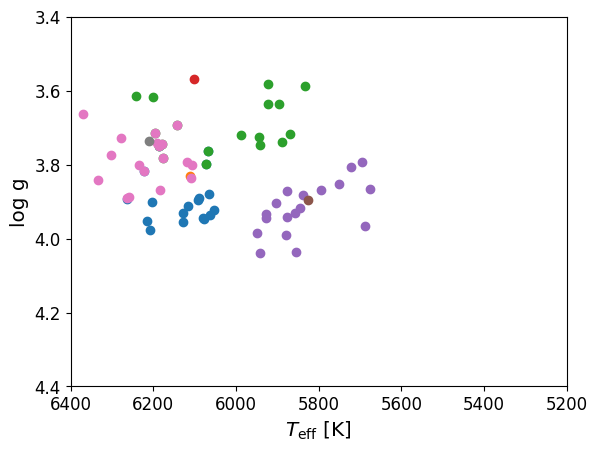

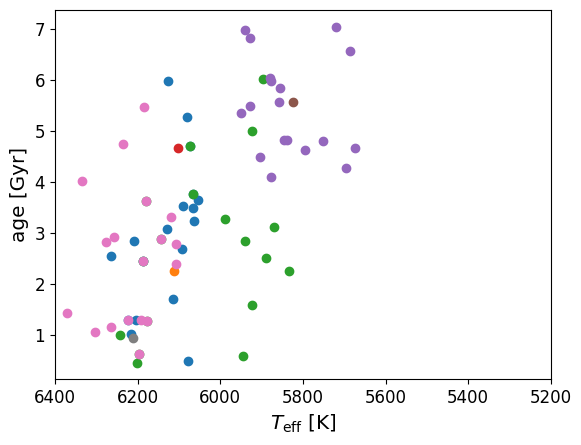

In [8]:
inferences_df_idx, inferences_df_matched = matched_sampling(training, inference_apogee)
inferences_df_idx
inference_apogee.iloc[inferences_df_idx[0]]

plt.scatter(inference_apogee.iloc[inferences_df_idx[0]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[0]]['aspcap_logg'])
plt.scatter(training.iloc[0]['aspcap_teff'], training.iloc[0]['aspcap_logg'])

plt.scatter(inference_apogee.iloc[inferences_df_idx[1]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[1]]['aspcap_logg'])
plt.scatter(training.iloc[1]['aspcap_teff'], training.iloc[1]['aspcap_logg'])

plt.scatter(inference_apogee.iloc[inferences_df_idx[2]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[2]]['aspcap_logg'])
plt.scatter(training.iloc[2]['aspcap_teff'], training.iloc[2]['aspcap_logg'])

plt.scatter(inference_apogee.iloc[inferences_df_idx[3]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[3]]['aspcap_logg'])
plt.scatter(training.iloc[3]['aspcap_teff'], training.iloc[3]['aspcap_logg'])
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlim([6400, 5200])
plt.ylim([4.4, 3.4]) 
plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.ylabel("log g")
plt.show()

# how about in age space?
plt.scatter(inference_apogee.iloc[inferences_df_idx[0]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[0]]['Age_pred'])
plt.scatter(training.iloc[0]['aspcap_teff'], training.iloc[0]['Age_pred'])

plt.scatter(inference_apogee.iloc[inferences_df_idx[1]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[1]]['Age_pred'])
plt.scatter(training.iloc[1]['aspcap_teff'], training.iloc[1]['Age_pred'])

plt.scatter(inference_apogee.iloc[inferences_df_idx[2]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[2]]['Age_pred'])
plt.scatter(training.iloc[2]['aspcap_teff'], training.iloc[2]['Age_pred'])

plt.scatter(inference_apogee.iloc[inferences_df_idx[3]]['aspcap_teff'], inference_apogee.iloc[inferences_df_idx[3]]['Age_pred'])
plt.scatter(training.iloc[3]['aspcap_teff'], training.iloc[3]['Age_pred'])
plt.ylabel('age [Gyr]')
plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.gca().invert_xaxis()
plt.xlim([6400, 5200])
plt.show()

In [9]:
scaling_factor = int(np.floor(len(inference_apogee)/len(training)))
age_residuals = []
for i in range(len(training)):
	inference_cluster = inference_apogee.iloc[inferences_df_idx[i]]
	#age_residual = np.sqrt(np.nansum(inference_cluster['Age_pred']-training.iloc[i]['Age_pred'])**2)
	inference_cluster_age_average = np.nanmean(inference_cluster['Age_pred'])
	age_residual = np.abs(inference_cluster_age_average - training.iloc[i]['Age_pred'])
	age_residuals.append(age_residual)


In [10]:
print(np.nanmean(age_residuals), np.std(age_residuals), np.median(age_residuals))

1.0213136159095852 0.889656934284808 0.727591050407508


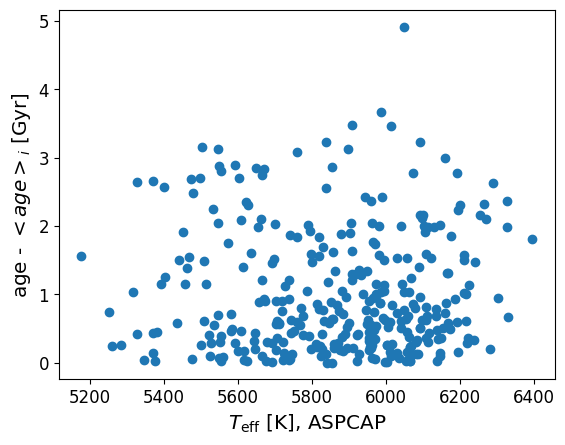

In [11]:
plt.scatter(training['aspcap_teff'], age_residuals)
plt.xlabel(r"$T_{\rm eff}$ [K], ASPCAP")
plt.ylabel(r'age - $<age>_i$ [Gyr]')
plt.show()

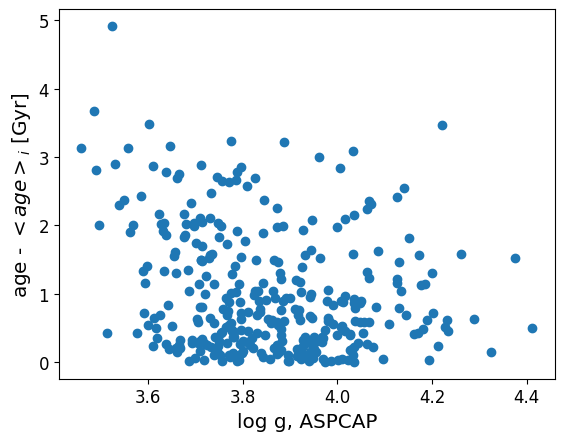

In [12]:
plt.scatter(training['aspcap_logg'], age_residuals)
plt.xlabel(r"log g, ASPCAP")
plt.ylabel(r'age - $<age>_i$ [Gyr]')
plt.show()

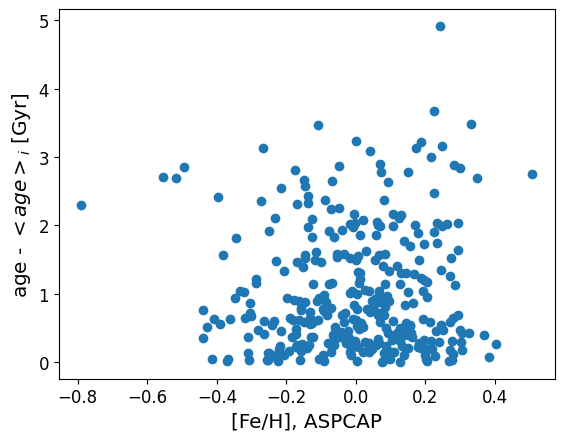

In [13]:
plt.scatter(training['aspcap_fe_h'], age_residuals)
plt.xlabel(r"[Fe/H], ASPCAP")
plt.ylabel(r'age - $<age>_i$ [Gyr]')
plt.show()

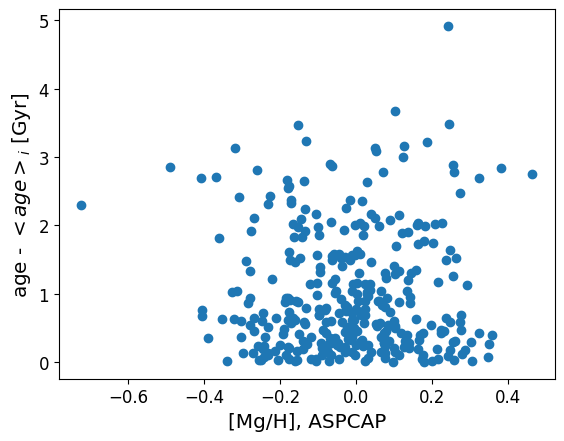

In [14]:
plt.scatter(training['aspcap_mg_h'], age_residuals)
plt.xlabel(r"[Mg/H], ASPCAP")
plt.ylabel(r'age - $<age>_i$ [Gyr]')
plt.show()

#### Read in silver set inferences, then minus two stars above chisq of 100000

In [22]:
silver_inferences_kic = pd.read_csv(path+'data/silver_inferences_kic_no_rgb.csv')
leave_out = silver_inferences_kic.loc[silver_inferences_kic['chisq']>=100000]

#silver_inferences_kic_head = silver_inferences_kic[['kepid','sdss_id','Teff_pred','logg_pred','fe_h_pred','mg_h_pred','Age_pred','Dnu_pred','chisq','sigma_star_Teff','sigma_star_logg','sigma_star_fe_h','sigma_star_mg_h','sigma_star_age','sigma_star_Dnu']].head()
silver_inferences_kic = silver_inferences_kic.loc[silver_inferences_kic['chisq']<100000]
print(silver_inferences_kic)
print(list(silver_inferences_kic.columns))

       sdss_id        source_id_dr2         chisq      mg_h    e_mg_h  \
0     66647246  2050248268478160768  15172.682644  0.076918  0.018866   
1     66647251  2050248955672927744  14055.942762 -0.053333  0.019602   
2     66647134  2050239098734955648  11391.076823 -0.001719  0.021841   
3     66647198  2050243634220456448  13304.715253 -0.178137  0.022604   
4     66668021  2051692820600980096  52897.546033  0.184666  0.014077   
...        ...                  ...           ...       ...       ...   
3807  67800923  2139303075330917760  12770.052000 -0.044575  0.024842   
3808  67800812  2139291152503580800  15196.706056 -0.073302  0.020401   
3809  67800943  2139305209933710336  14979.405227 -0.061446  0.024190   
3810  67800878  2139297680852810368  13470.311444 -0.177313  0.026742   
3811  67801064  2139320220841804416  10345.148206 -0.199759  0.033598   

         kepid            source_id  teff  teff_err1  teff_err2  ...  \
0      1025494  2050248268478160768  6120      183.

In [23]:
pd.merge(inferences_df[['sdss_id','KIC']], leave_out[['sdss_id','chisq']], on='sdss_id')

,sdss_id,KIC,chisq
0,66681442,3341831,111213.669638
1,67091655,6467256,132663.206325


In [30]:
print(np.max(silver_inferences_kic['teff'])+1, np.min(silver_inferences_kic['teff'])-1)
print(np.max(silver_inferences_kic['logg'])+0.01, np.min(silver_inferences_kic['logg'])-0.01)

6396 5176
4.420999999999999 3.45


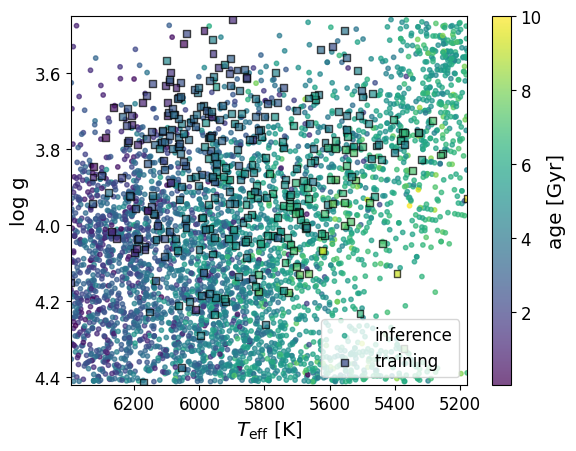

In [31]:
### now we do this with continuous ages rather than four discrete chunks
#plt.scatter(inferences_df_matched.teff, inferences_df_matched.logg, s=5, alpha=0.7, c=inferences_df_matched['Age_pred'], label='inference') # teff or Teff_pred? choose wisely
#plt.scatter(inferences_df_culled['aspcap_teff'], inferences_df_culled['aspcap_logg'], s=10, alpha=0.7, c=inferences_df_culled['Age_pred'], label='inference') # teff or Teff_pred? choose wisely
plt.scatter(silver_inferences_kic['teff'], silver_inferences_kic['logg'], s=10, alpha=0.7, c=silver_inferences_kic['Age_pred'], label='inference') # teff or Teff_pred? choose wisely
plt.scatter(training['aspcap_teff'], training['aspcap_logg'], marker='s', s=25, alpha=0.7, c=training['Age_pred'], edgecolors='k', linewidths=1, label='training')
plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.ylabel('log g')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlim([np.max(silver_inferences_kic['teff'])+1, np.min(silver_inferences_kic['teff'])-1])
plt.ylim([np.max(silver_inferences_kic['logg'])+0.01, np.min(silver_inferences_kic['logg'])-0.01])
#plt.xlim([6600, 4800])
#plt.ylim([4.52, 3.3]) # 
plt.legend(loc='lower right')
plt.colorbar(label='age [Gyr]')
#plt.savefig(path+'plots/kiel_silver_gold.png')
plt.savefig(path+'plots/kiel_silver_training.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [18]:
inferences_df_culled.to_csv(path+'data/inferences_kic_culled.csv', index=False)

Residual analysis of gold (matched sampling) sample

In [31]:
inferences_df_matched

,kepid_x,source_id,sdss_id,teff_x,teff_err1,teff_err2,logg_x,logg_err1,logg_err2,feh_x,...,KIC,kepid_y,teff_y,logg_y,feh_y,mg_h_y,aspcap_teff,aspcap_logg,aspcap_fe_h,aspcap_mg_h
3457,8949569,2127031327275591040,67666623,5549.5470,165.0,-165.0,3.828,0.280,-0.100,-0.20,...,8949569,8949569,6116,3.828,-0.20,-0.203938,6116,3.828,-0.20,-0.203938
3540,9073645,2107192594157600000,67474416,5809.1450,81.0,-81.0,3.835,0.020,-0.014,0.00,...,9073645,9073645,6108,3.835,0.00,-0.092286,6108,3.835,0.00,-0.092286
915,4571904,2076446748656151680,67108491,6005.1216,102.0,-65.0,3.830,0.020,-0.018,-0.04,...,4571904,4571904,6120,3.830,-0.04,0.054967,6120,3.830,-0.04,0.054967
1902,6542321,2076950531142505088,67115118,5901.5250,164.0,-164.0,3.851,0.308,-0.103,-0.30,...,6542321,6542321,6106,3.851,-0.30,0.101896,6106,3.851,-0.30,0.101896
5929,12069569,2135363456449119616,67765417,6081.1600,82.0,-82.0,3.836,0.030,-0.020,-0.04,...,12069569,12069569,6137,3.836,-0.04,-0.140554,6137,3.836,-0.04,-0.140554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3992,9579080,2130415108667989120,67707208,5986.4077,161.0,-161.0,3.946,0.280,-0.120,-0.30,...,9579080,9579080,6365,3.946,-0.30,-0.148839,6365,3.946,-0.30,-0.148839
220,2834481,2099198874045282688,67384478,5992.2456,160.0,-160.0,3.968,0.259,-0.130,-0.08,...,2834481,2834481,6350,3.968,-0.08,-0.169142,6350,3.968,-0.08,-0.169142
2908,8258061,2079017784799278464,67140644,6276.8720,175.0,-175.0,3.932,0.280,-0.120,-0.38,...,8258061,8258061,6366,3.932,-0.38,-0.226585,6366,3.932,-0.38,-0.226585
3137,8579578,2079268297345363456,67143604,6277.8384,69.0,-81.0,3.913,0.015,-0.013,0.08,...,8579578,8579578,6343,3.913,0.08,-0.043607,6343,3.913,0.08,-0.043607
